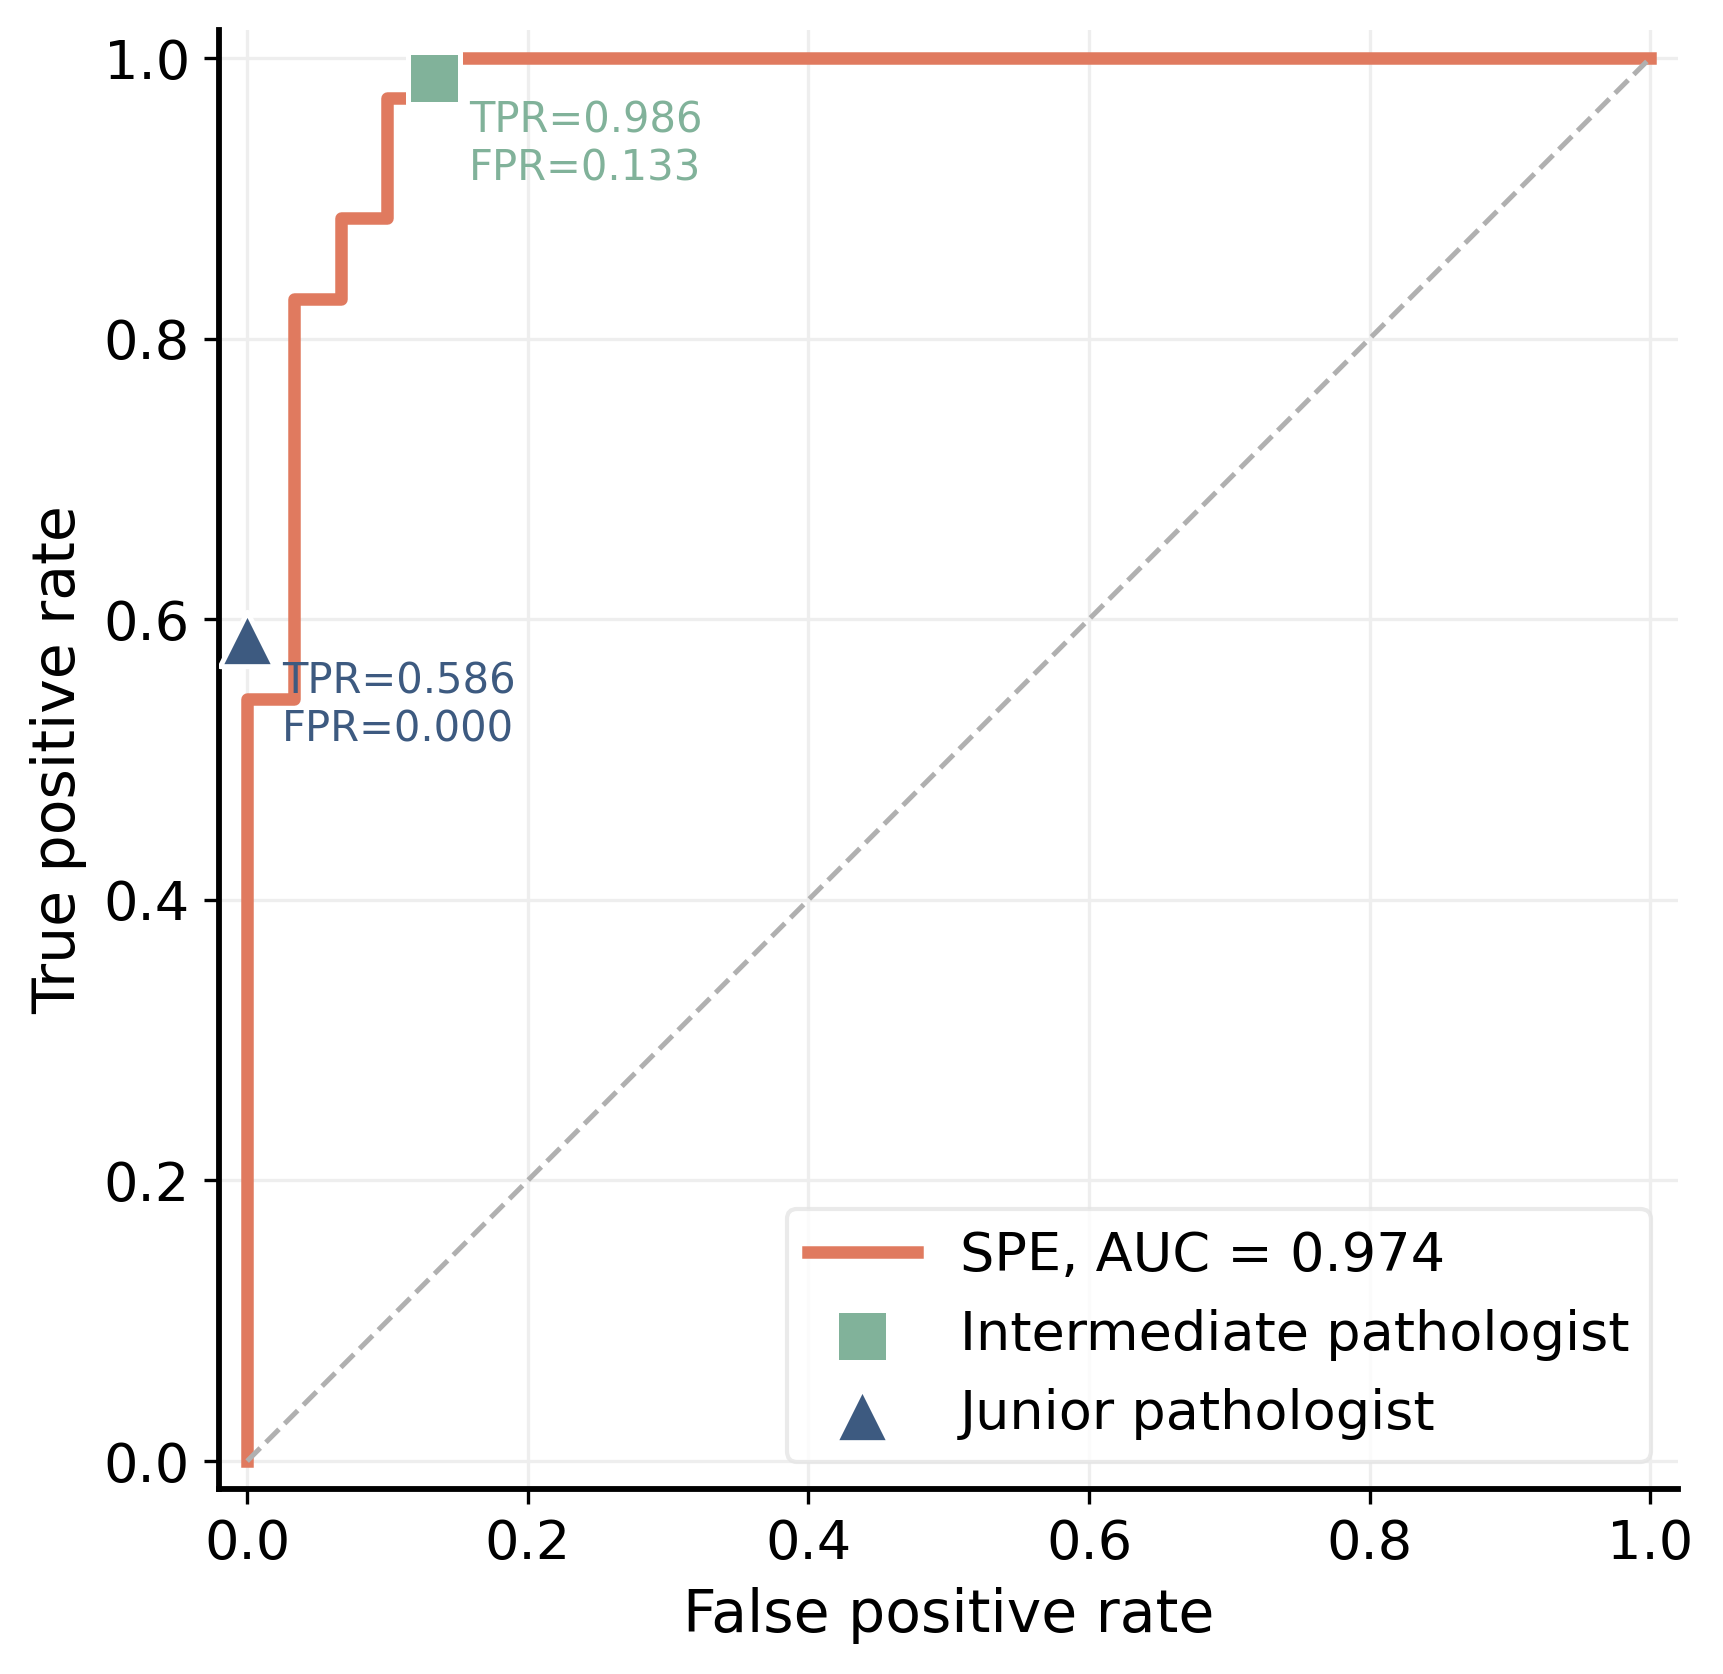

In [18]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, roc_curve

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'axes.labelsize': FS,
    'xtick.labelsize': FS - 1,
    'ytick.labelsize': FS - 1,
    'legend.fontsize': FS - 1,
    'axes.unicode_minus': False
})

df = pd.read_csv('/NAS2/Data1/lbliao/Code-195/MIL_BASELINE/datasets/Contrast/External/result2.csv')
df['p'] = df['probs'].apply(lambda x: float(ast.literal_eval(x)[1]) if pd.notna(x) else np.nan)
df = df.dropna(subset=['p'])

y = df['test_label'].values
p = df['p'].values

def op(pred):
    return np.mean(pred[y == 0] == 1), np.mean(pred[y == 1] == 1)

fpr_a, tpr_a = op(df['a'].values)
fpr_b, tpr_b = op(df['b'].values)
fpr, tpr, _ = roc_curve(y, p)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6.2, 5.8), dpi=300)

colors = {
    'SPE': '#E07A5F',
    'Intermediate': '#81B29A',
    'Junior': '#3D5A80'
}

ax.plot(fpr, tpr, lw=3, color=colors['SPE'],
        label=f'SPE, AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], '--', lw=1.2, color='#B0B0B0')

ax.scatter(fpr_a, tpr_a, s=150, marker='s', color=colors['Intermediate'],
           edgecolors='white', linewidths=1.2, label='Intermediate pathologist', zorder=3)
ax.scatter(fpr_b, tpr_b, s=170, marker='^', color=colors['Junior'],
           edgecolors='white', linewidths=1.2, label='Junior pathologist', zorder=3)

ax.text(fpr_a + 0.025, tpr_a - 0.015,
        f'TPR={tpr_a:.3f}\nFPR={fpr_a:.3f}',
        color=colors['Intermediate'], fontsize=10, va='top')
ax.text(fpr_b + 0.025, tpr_b - 0.015,
        f'TPR={tpr_b:.3f}\nFPR={fpr_b:.3f}',
        color=colors['Junior'], fontsize=10, va='top')

ax.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
       xlabel='False positive rate', ylabel='True positive rate')
ax.set_aspect('equal')
ax.grid(color='#eeeeee', lw=0.8)
ax.legend(loc='lower right', frameon=True, edgecolor='#e5e5e5')

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(1.4)

plt.tight_layout()
plt.savefig('result-combat/roc.svg', bbox_inches='tight', facecolor='white')
plt.show()

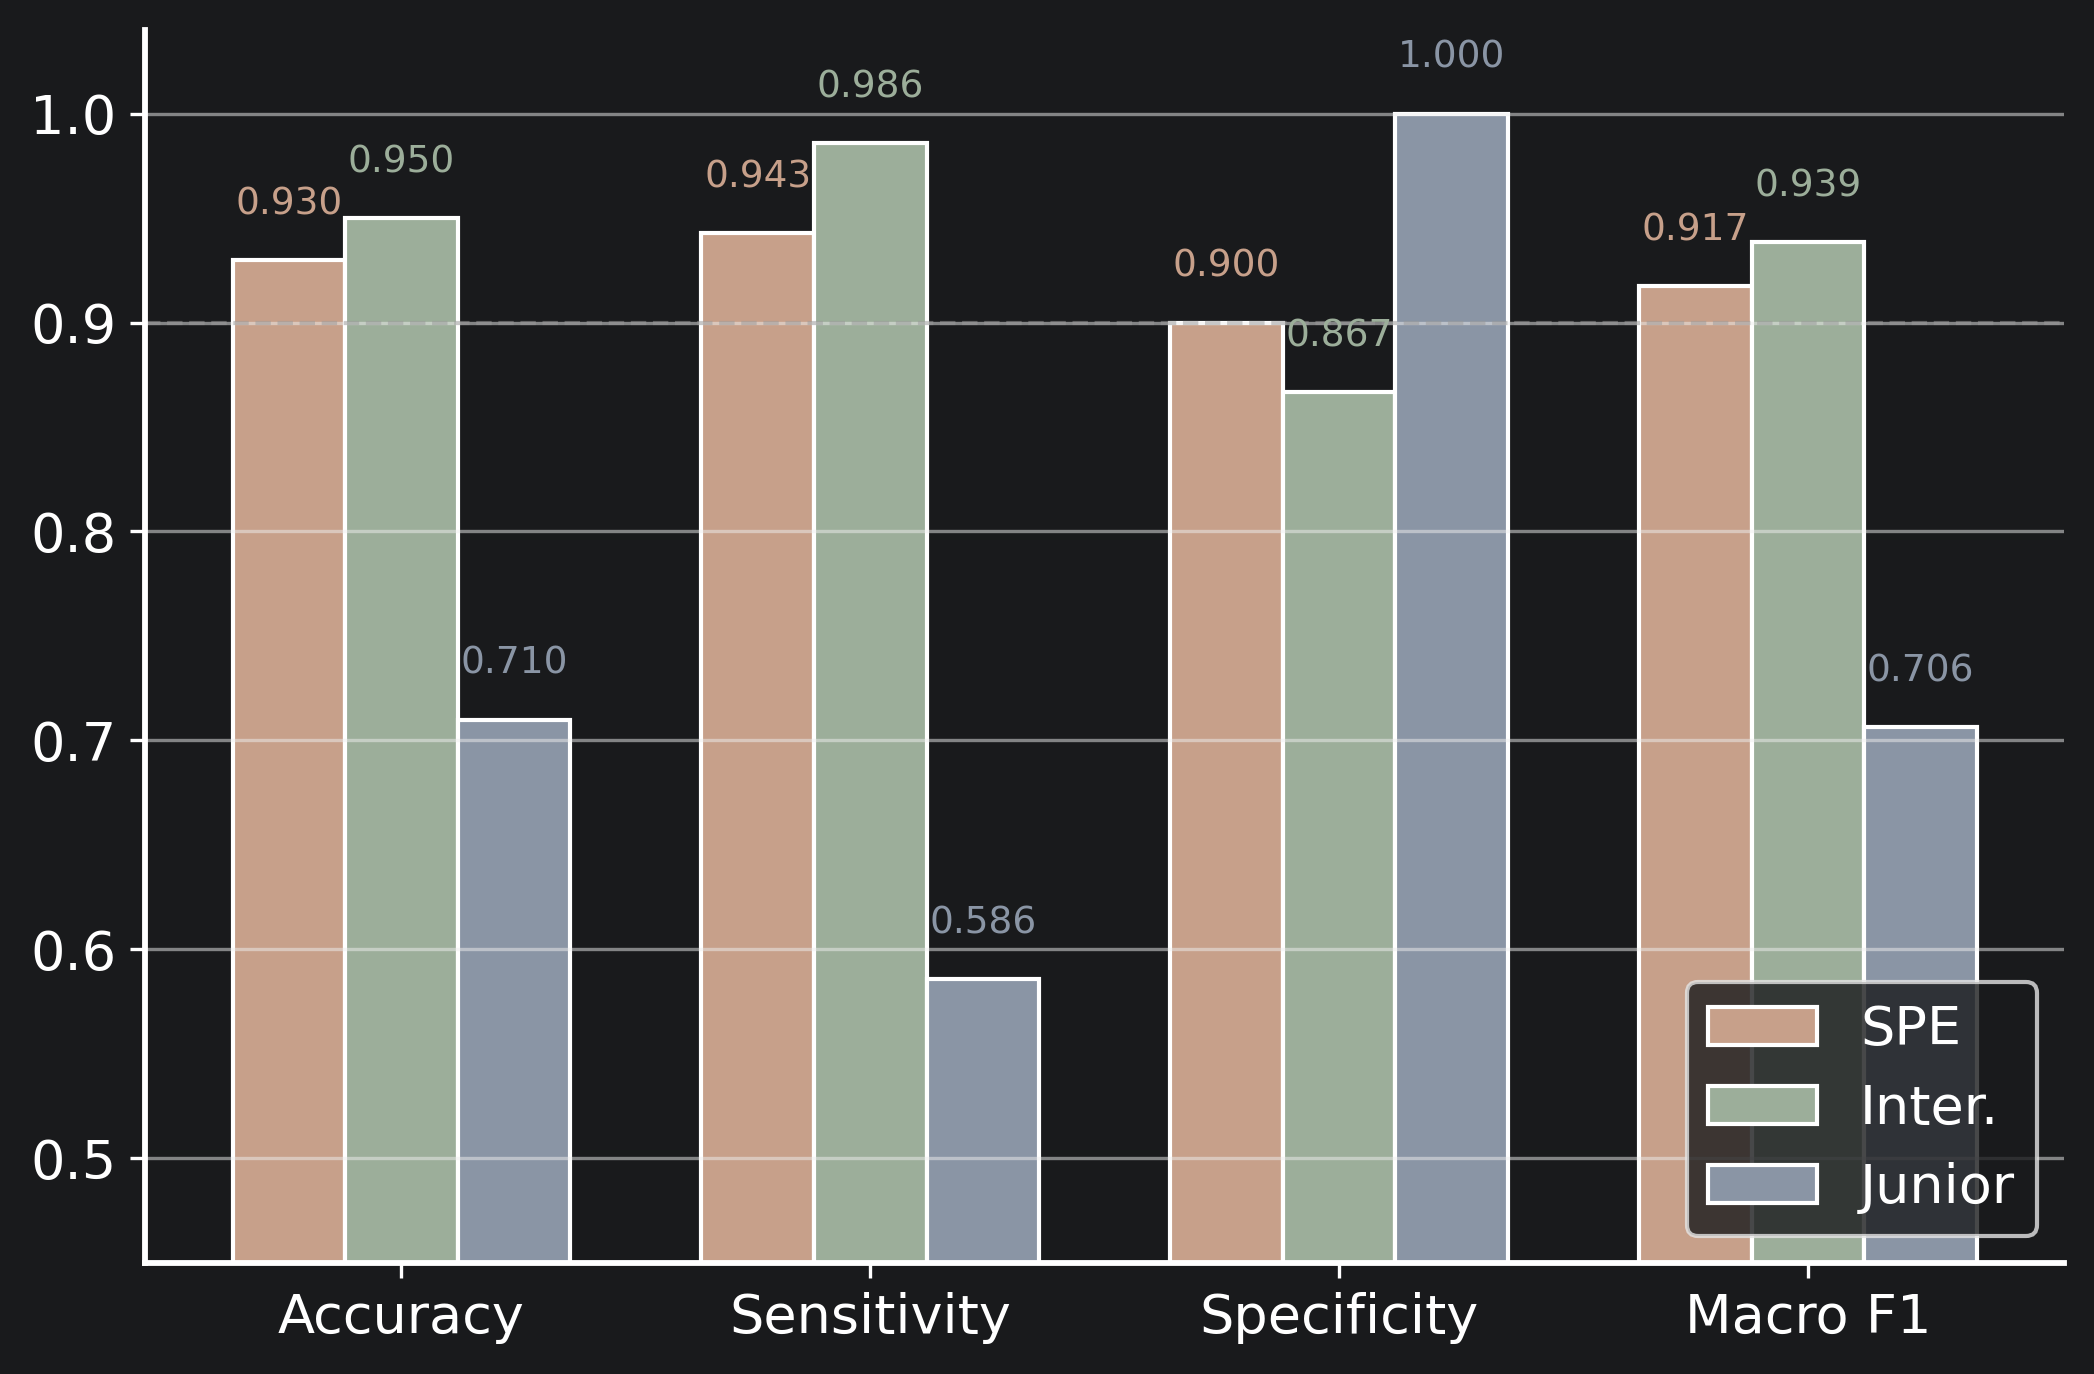

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'xtick.labelsize': FS - 1,
    'ytick.labelsize': FS - 1,
    'legend.fontsize': FS - 1,
    'axes.unicode_minus': False
})

df = pd.read_csv('/NAS2/Data1/lbliao/Code-195/MIL_BASELINE/datasets/Contrast/External/result2.csv')
y = df['test_label'].values

groups = {
    'SPE': df['prediction'].values,
    'Inter.': df['a'].values,
    'Junior': df['b'].values
}

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Macro F1']
colors = {
    'SPE': '#C7A08A',
    'Inter.': '#9CAE9A',
    'Junior': '#8A95A5'
}

def calc(t, p):
    tp = ((p == 1) & (t == 1)).sum()
    tn = ((p == 0) & (t == 0)).sum()
    fp = ((p == 1) & (t == 0)).sum()
    fn = ((p == 0) & (t == 1)).sum()

    f1_malignant = ( 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0 ) # Benign class: class 0
    f1_benign = ( 2 * tn / (2 * tn + fp + fn) if (2 * tn + fp + fn) > 0 else 0 )
    macro_f1 = (f1_malignant + f1_benign) / 2
    return {
        'Accuracy': (tp + tn) / len(t),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'Macro F1': macro_f1
    }

res = {g: calc(y, p) for g, p in groups.items()}

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=300)

x = np.arange(len(metrics))
w = 0.24

for i, (g, c) in enumerate(colors.items()):
    vals = [res[g][m] for m in metrics]
    xpos = x + (i - 1) * w
    ax.bar(xpos, vals, width=w, color=c, edgecolor='white', linewidth=1.0, label=g)

    for xx, v in zip(xpos, vals):
        ax.text(xx, v + 0.018, f'{v:.3f}', ha='center',
                va='bottom', fontsize=9, color=c)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.45, 1.04)
ax.set_yticks(np.arange(0.5, 1.01, 0.1))

ax.axhline(0.9, color='#999999', ls='--', lw=1, alpha=0.5)
ax.grid(axis='y', color='#eeeeee', lw=0.8)
ax.legend(loc='lower right', frameon=True, edgecolor='#e5e5e5')

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(1.4)

plt.tight_layout()
plt.savefig('result-combat/grouped_bar_combat.svg', bbox_inches='tight', facecolor='white')
plt.show()

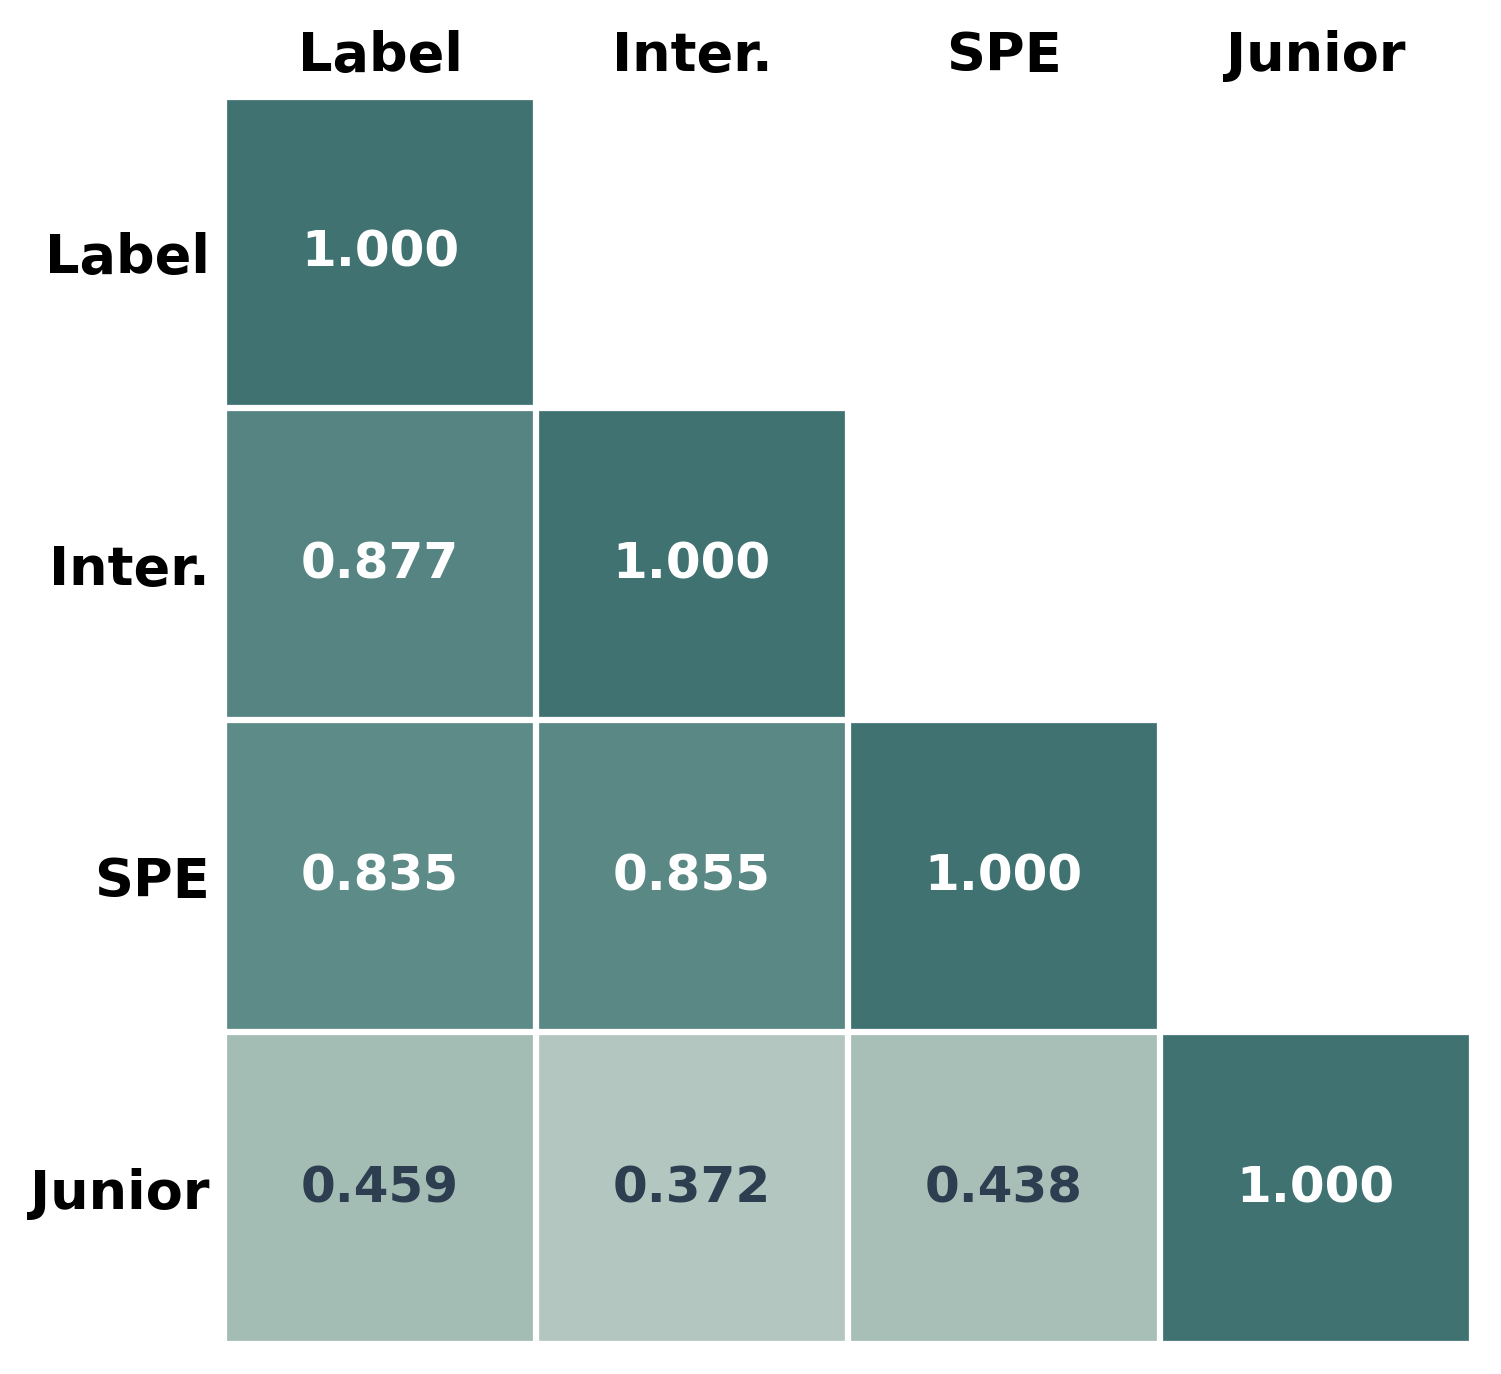

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'xtick.labelsize': FS - 1,
    'ytick.labelsize': FS - 1,
    'axes.unicode_minus': False
})

names = ['Label', 'Inter.', 'SPE', 'Junior']
kappa = pd.DataFrame(
    [
        [1.000, 0.877, 0.835, 0.459],
        [0.877, 1.000, 0.855, 0.372],
        [0.835, 0.855, 1.000, 0.438],
        [0.459, 0.372, 0.438, 1.000],
    ],
    index=names,
    columns=names
)

cmap = LinearSegmentedColormap.from_list('morandi', ['#F2ECE6', '#CAD8D1', '#9CB7AF', '#6E9994', '#3F7271'] )

mask = np.triu(np.ones_like(kappa, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(5.2, 4.8), dpi=300)
im = ax.imshow(kappa, cmap=cmap, vmin=0, vmax=1)

for i in range(len(names)):
    for j in range(len(names)):
        if mask[i, j]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       color='white', ec='white'))
        else:
            v = kappa.iloc[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=FS - 2, fontweight='bold',
                    color='white' if v >= 0.65 else '#2C3E50')

for i in np.arange(-0.5, len(names), 1):
    ax.axhline(i, color='white', lw=1.5)
    ax.axvline(i, color='white', lw=1.5)

ax.set_xticks(np.arange(len(names)))
ax.set_yticks(np.arange(len(names)))
ax.set_xticklabels(names, fontweight='bold')
ax.set_yticklabels(names, fontweight='bold')
ax.xaxis.tick_top()
ax.tick_params(length=0)

# cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.set_label("Cohen's $\kappa$", fontsize=FS - 1)
# cbar.ax.tick_params(labelsize=FS - 2)

ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig('result-combat/kappa_heatmap_lower.svg', bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_3682052/1341815354.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


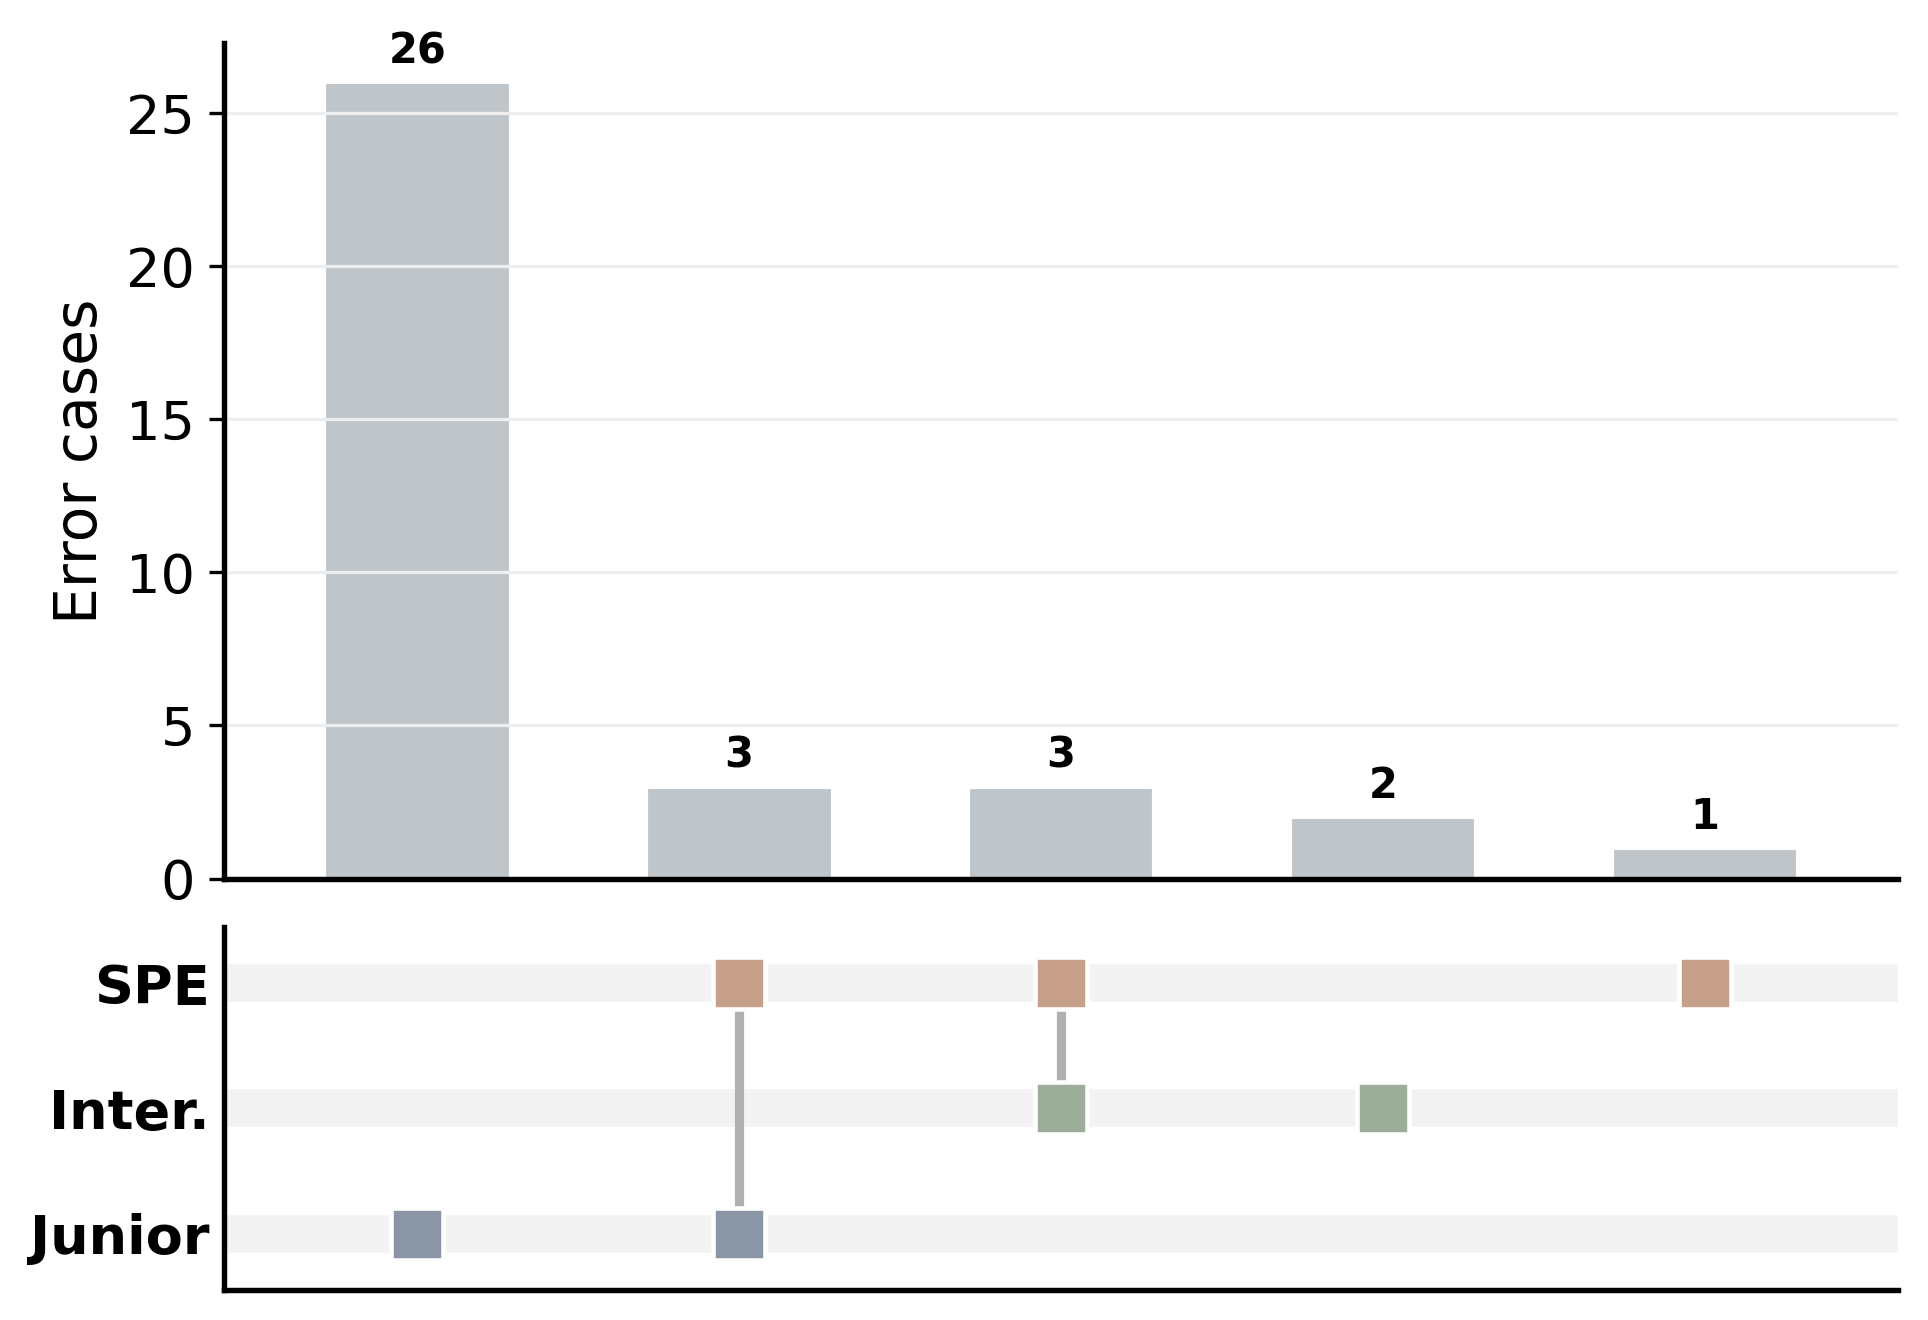

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'xtick.labelsize': FS - 2,
    'ytick.labelsize': FS - 1,
    'axes.unicode_minus': False
})

df = pd.read_csv('/NAS2/Data1/lbliao/Code-195/MIL_BASELINE/datasets/Contrast/External/result2.csv')
y = df['test_label'].values

errs = np.column_stack([
    df['prediction'].values != y,
    df['a'].values != y,
    df['b'].values != y
])

codes = errs @ np.array([4, 2, 1])
counts = pd.Series(codes).value_counts().drop(0, errors='ignore').sort_values(ascending=False)

names = ['SPE', 'Inter.', 'Junior']
bits = [4, 2, 1]
ys = [2, 1, 0]
colors = {'SPE': '#C7A08A', 'Inter.': '#9CAE9A', 'Junior': '#8A95A5'}

fig, (ax_bar, ax_mat) = plt.subplots(
    2, 1,
    figsize=(7.2, 5.4),
    dpi=300,
    gridspec_kw={'height_ratios': [2.3, 1], 'hspace': 0.08}
)

x = np.arange(len(counts))

ax_bar.bar(x, counts.values, width=0.58, color='#BFC5C9', edgecolor='white')
for xx, v in zip(x, counts.values):
    ax_bar.text(xx, v + 0.35, str(int(v)),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_bar.set_ylabel('Error cases')
ax_bar.set_xticks([])
ax_bar.grid(axis='y', color='#eeeeee', lw=0.8)

for y0 in ys:
    ax_mat.axhline(y0, color='#F3F3F3', lw=9, zorder=0)

for i, code in enumerate(counts.index):
    present = [j for j, b in enumerate(bits) if code & b]
    y_present = [ys[j] for j in present]

    if len(y_present) > 1:
        ax_mat.plot([i, i], [min(y_present), max(y_present)],
                    color='#B0B0B0', lw=2.2, zorder=1)

    for j in present:
        ax_mat.scatter(i, ys[j], s=150, marker='s',
                       color=colors[names[j]], edgecolors='white',
                       linewidths=1.1, zorder=2)

ax_mat.set_xlim(-0.6, len(counts) - 0.4)
ax_bar.set_xlim(ax_mat.get_xlim())

ax_mat.set_ylim(-0.45, 2.45)
ax_mat.set_xticks([])
ax_mat.set_yticks(ys)
ax_mat.set_yticklabels(names, fontweight='bold')
ax_mat.tick_params(axis='y', length=0)

for ax in [ax_bar, ax_mat]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(1.3)

plt.tight_layout()
plt.savefig('result-combat/upset_error.svg', bbox_inches='tight', facecolor='white')
plt.show()